<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 9.1: NN with Keras
INSTRUCTIONS:
- Read the guides and hints, then create the necessary analysis and code to find an answer and conclusion for the task below.
- **NOTE**: This is a Regression problem. Consider the appropriate:
    - Activation function
    - Loss/Cost Function
    - Metrics

### Import libraries

In [3]:
# insert code here

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


### Load data
Load the Diabetes dataset from **SciKit-Learn**.

In [2]:
# insert code here
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [6]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

### Prepare input data

In [ ]:
# insert code here


### Split the data (training/test)

In [8]:
# insert code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Create the model's architecture

In [9]:
# insert code here
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # Linear activation by default
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile the model

In [10]:
# insert code here
model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])

### Fit the training data

In [11]:
%%time
# insert code here
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2, verbose=0)

CPU times: user 13.2 s, sys: 660 ms, total: 13.8 s
Wall time: 16.1 s


### Create predictions

In [12]:
# insert code here
y_pred = model.predict(X_test_scaled).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


### Evaluate the model

In [13]:
# insert code here
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")


Mean Squared Error: 2879.67
Mean Absolute Error: 42.57


### Visualisation of cost

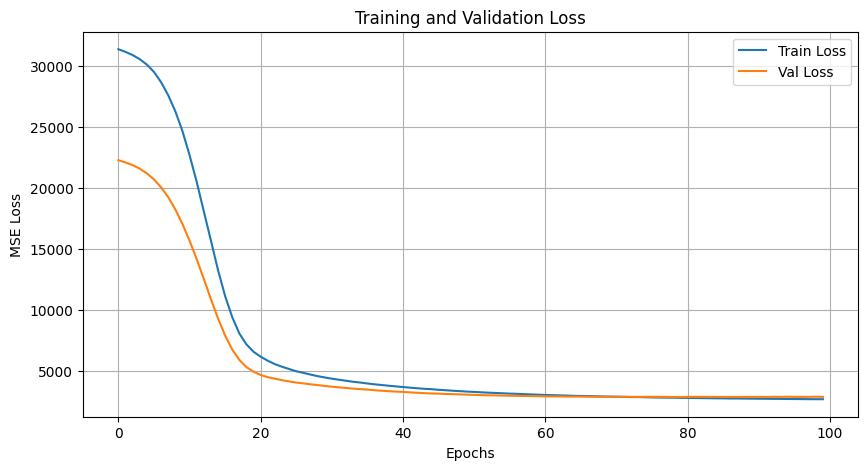

In [14]:
# insert code here
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


### Visualisation of residuals

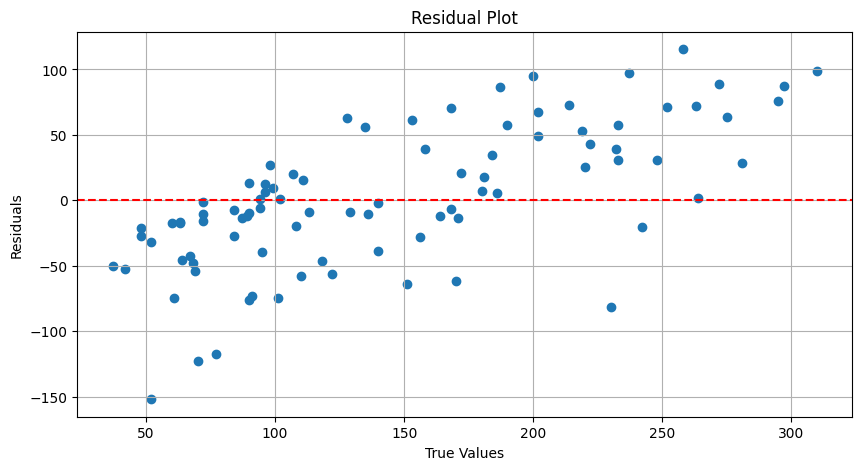

In [15]:
# insert code here
residuals = y_test - y_pred
plt.figure(figsize=(10,5))
plt.scatter(y_test, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('True Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)
plt.show()



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



